# Efficiency and Dark counts
Data from cooldown 4:
* 27/01/2026
* 28/01/2026

In [1]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import datetime
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
import qil_Visa.visa as visa
import pyvisa
from IPython.display import clear_output,display

In [3]:
# Import helpers
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")
import qil_helpers.Angela.snspd as snshp
import qil_helpers.Angela.experimentHelpers as exhp
import qil_helpers.Angela.plottingHelpers as plhp

Laser didn't settle
Power/wavelength/frequency/offset is out of range, enter the correct value!
Laser is off, turn it on!
XE flag returned execution error
Importing Functions


In [4]:
# Directory structure
current_file = 'efficiency and dark counts.ipynb'
current_dir = os.path.dirname(os.path.abspath(current_file)) # Angela Experiments
print(current_dir)
parent_dir = os.path.dirname(current_dir) # Longterm_sweeps
print(parent_dir)

# Append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(parent_dir)

c:\Users\Mario\Documents\GitHub\longterm_sweeps\analysis
c:\Users\Mario\Documents\GitHub\longterm_sweeps


In [27]:
# Plotting functions - UNDER SNSPDHELPERS CLASS
def plot_efficiency(efficiencyDf, setWavelength, wmFrequency, inputPower, colChoice, runID, date, ylimMax, save = False):
    fig, ax = plt.subplots()
    fig.set_size_inches(plhp.cm2inch(24, 15))

    h = 6.62607015e-34
    ePerPhoton = h * wmFrequency
    inputCounts = inputPower / ePerPhoton # /s

    voltage = -efficiencyDf['Bias Voltage (V)']
    current = efficiencyDf['Bias Current (mA)']
    efficiency = efficiencyDf['Efficiency (%)']
    counts = efficiencyDf['Count Rate (/s)']

    ax.plot(current, efficiency, c = colChoice)
    ax.set_xlabel(fr'Bias Current (mA)')
    ax.set_ylabel(fr'Efficiency (%)')
    # ax.set_xlim(min(current), max(current))
    ax.set_ylim([0, ylimMax])

    ax2 = ax.twiny()
    ax2.set_xlabel('-Bias Voltage (V)')
    ax2.plot(voltage, efficiency, alpha = 0)
    # ax2.set_xlim(min(voltage), max(voltage))

    sec = ax.twinx()
    sec.set_ylabel(fr'Raw Count Rate (s$^{-1}$)')
    sec.plot(current, counts, alpha = 0)
    sec.set_ylim(0, (ylimMax/max(efficiency)) * max(counts))
    # sec.set_xlim(min(current), max(current))

    plt.suptitle(fr'Efficiency vs. Bias Current at {setWavelength}nm, {int(np.round(inputCounts))} Photons/Exc ({date})')
    plt.tight_layout() 
    if save == True:
        dateString = time.strftime('%Y-%m-%d')
        plotPath = fr'plots/{dateString}'
        os.makedirs(plotPath, exist_ok=True)
        plt.savefig(fr'{plotPath}/efficiency{runID}.jpg')
    plt.show()
    
    return

def plot_dark(darkDf, ylims, colChoice, runID, date, save = False):
    fig, ax = plt.subplots()
    fig.set_size_inches(plhp.cm2inch(24, 15))

    voltage = -darkDf['Bias Voltage (V)']
    current = darkDf['Bias Current (mA)']
    counts = darkDf['Count Rate (/s)']

    ax.scatter(current, counts, c = colChoice)
    ax.set_xlabel(fr'Bias Current (mA)')
    ax.set_ylabel(fr'Count Rate (s$^{-1}$)')
    # ax.set_xlim(min(current), max(current))
    # ax.set_ylim([0, ylimMax])

    ax2 = ax.twiny()
    ax2.set_xlabel('-Bias Voltage (V)')
    ax2.scatter(voltage, counts, alpha = 0)
    # ax2.set_xlim(min(voltage), max(voltage))

    plt.suptitle(fr'Dark Counts vs. Bias Current ({date}) - Run {runID}')
    plt.ylim([ylims[0], ylims[1]])
    plt.tight_layout() 
    if save == True:
        dateString = time.strftime('%Y-%m-%d')
        plotPath = fr'plots/{dateString}'
        os.makedirs(plotPath, exist_ok=True)
        plt.savefig(fr'{plotPath}/efficiency{runID}.jpg')
    plt.show()
    
    return

# Efficiencies

In [9]:
# Measurement Parameters
intTime = 2 # s

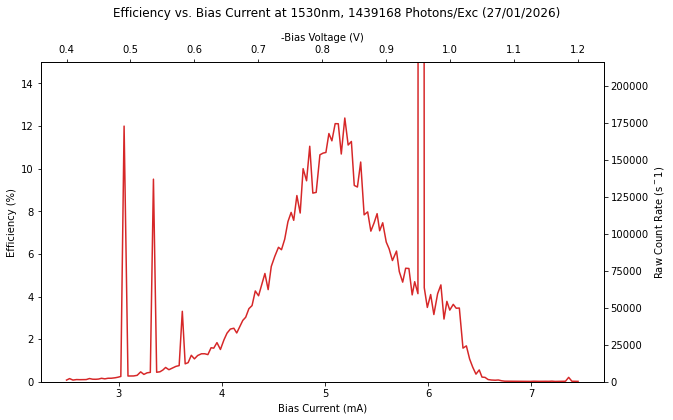

In [ ]:
# Run 1
countTimeRatio = 200/400 # ms

# Measure power going to SNSPDs before OOMs (using only slip and slop)
preOOMPower = 2.463e-3 # at 80mA on TimTam, 1530nm
OOM1 = -44.1
OOM2 = -57.1
attenuation = OOM1 + OOM2

eff1 = snshp.process_efficiency(r'C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-01-27\efficiency\efficiency1.csv',
                                inputPower = preOOMPower * 10**(attenuation/10),
                                intTime = 2,
                                countTimeRatio = 200/400,
                                wmFrequency = 195.92821655273437e12) 

snshp.plot_efficiency(eff1, 1530, wmFrequency = 195.92821655273437e12,
                      inputPower = preOOMPower * 10**(attenuation/10),
                      colChoice = 'tab:red',
                      runID = 1, date = '27/01/2026',
                      ylimMax = 15,
                      save = False)

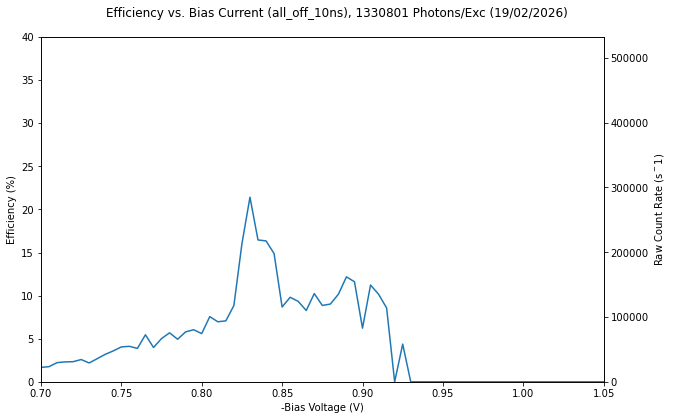

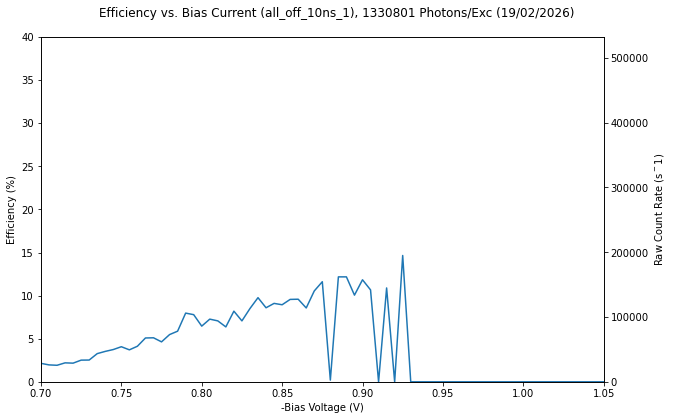

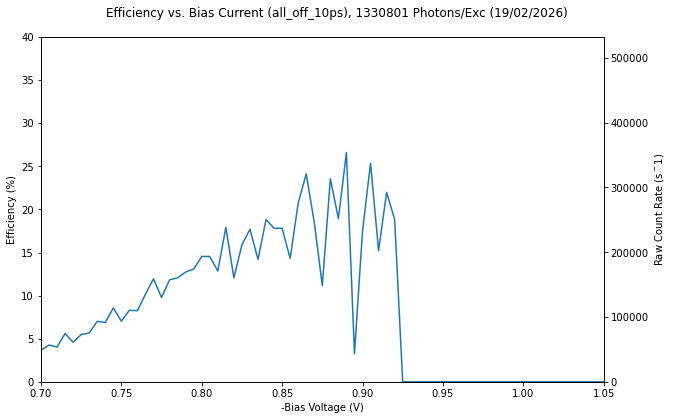

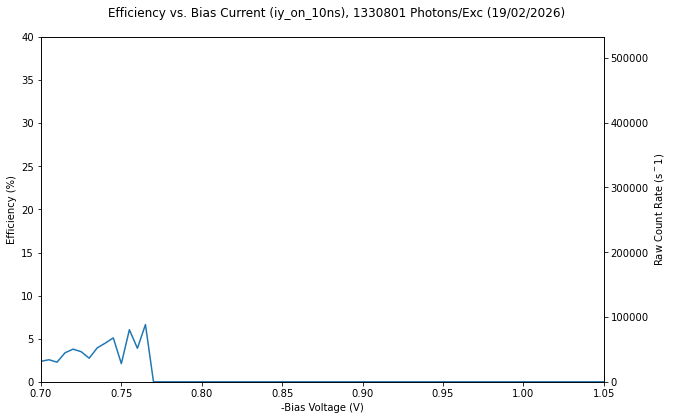

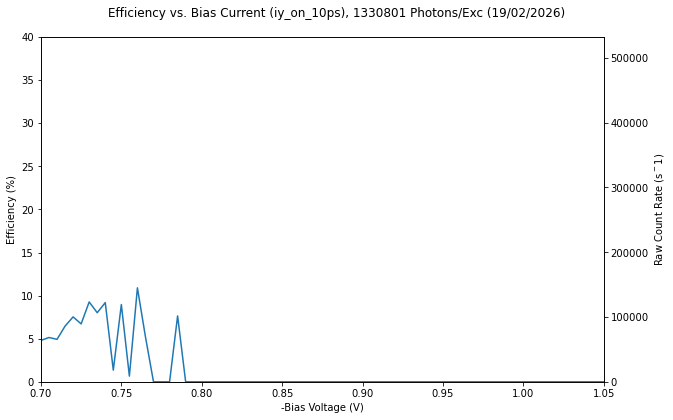

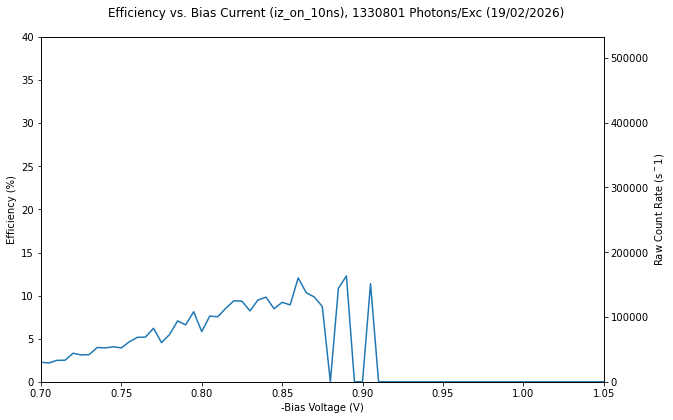

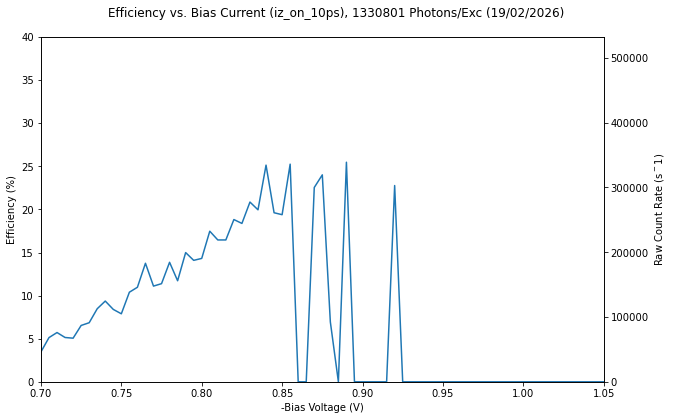

In [39]:
# Run 2
# Measure power going to SNSPDs before OOMs (using slip slop and FOS1)
preOOMPower = 2.290e-3 # at 90mA on TimTam, 1530nm
OOM1 = -44.1
OOM2 = -57.1
attenuation = OOM1 + OOM2
folder = r'C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/2026-02-19/efficiency/'

for csv in os.listdir(folder):
    file_path = os.path.join(folder, csv)
    file_name = os.path.split(file_path)[-1]
    ID = file_name[:-4]

    eff = snshp.process_efficiency(file_path,
                    inputPower = preOOMPower * 10**(attenuation/10), 
                    intTime = 2,
                    countTimeRatio = 200/600, 
                    wmFrequency = 197e12) # Hz

    plot_efficiency(eff, 
                ID = ID, 
                wmFrequency = 197e12,
                inputPower = preOOMPower * 10**(attenuation/10),
                colChoice = 'tab:blue',
                runID = fr'_{ID}',
                date = '19/02/2026',
                ylimMax = 40,
                save = True)

# Dark Counts

In [5]:
# adjust to plot values from uni-t dmm

def plot_efficiency(efficiencyDf, ID, wmFrequency, inputPower, colChoice, runID, date, ylimMax, save = False):
    fig, ax = plt.subplots()
    fig.set_size_inches(plhp.cm2inch(24, 15))

    h = 6.62607015e-34
    ePerPhoton = h * wmFrequency
    inputCounts = inputPower / ePerPhoton # /s

    voltage = -efficiencyDf['Bias Voltage (V)']
    current = efficiencyDf['Bias Current (mA)']
    efficiency = efficiencyDf['Efficiency (%)']
    counts = efficiencyDf['Count Rate (/s)']

    ax.plot(voltage, efficiency, c = colChoice)
    ax.set_xlabel(fr'-Bias Voltage (V)')
    ax.set_ylabel(fr'Efficiency (%)')
    # ax.set_xlim(min(current), max(current))
    ax.set_ylim([0, ylimMax])

    # ax2 = ax.twiny()
    # ax2.set_xlabel(fr'Bias Current ($\mu$A)')
    # ax2.plot(current, efficiency, alpha = 0)
    # # ax2.set_xlim(min(voltage), max(voltage))

    sec = ax.twinx()
    sec.set_ylabel(fr'Raw Count Rate (s$^{-1}$)')
    sec.plot(voltage, counts, alpha = 0)
    sec.set_ylim(0, (ylimMax/max(efficiency)) * max(counts))
    sec.set_xlim(min(voltage), max(voltage))

    plt.suptitle(fr'Efficiency vs. Bias Current ({ID}), {int(np.round(inputCounts))} Photons/Exc ({date})')
    plt.tight_layout() 
    if save == True:
        dateString = time.strftime('%Y-%m-%d')
        plotPath = fr'C:/Users/Mario/Documents/GitHub/longterm_sweeps/plots/{dateString}/efficiency'
        os.makedirs(plotPath, exist_ok=True)
        plt.savefig(fr'{plotPath}/efficiency{runID}.jpg')
    plt.show()
    
    return

def plot_dark(darkDf, colChoice, ylim, runID, date, desc, save = False):
    fig, ax = plt.subplots()
    fig.set_size_inches(plhp.cm2inch(24, 15))

    voltage = darkDf['Bias Voltage (V)']
    counts = darkDf['Count Rate (/s)']

    boolMask = counts > ylim[1]
    countsMask = counts.copy()
    countsMask[boolMask] = 0
    colMask = np.full(len(counts), colChoice, dtype = object)
    colMask[boolMask] = 'tab:red'

    ax.set_xlabel('-Bias Voltage (V)')
    sort_idx = np.argsort(abs(voltage))
    voltage_sorted = voltage[sort_idx]
    counts_sorted = countsMask[sort_idx]
    cols_sorted = colMask[sort_idx]
    ax.scatter(abs(voltage_sorted), counts_sorted, c = cols_sorted)
    ax.set_ylim([ylim[0], ylim[1]])

    plt.suptitle(fr'Dark Counts vs. Bias Current ({date}) - {desc}')
    plt.tight_layout() 
    if save == True:
        dateString = time.strftime('%Y-%m-%d')
        plotPath = fr'C:/Users/Mario/Documents/GitHub/longterm_sweeps/plots/{dateString}/dark'
        os.makedirs(plotPath, exist_ok = True)
        plt.savefig(fr'{plotPath}/dark_{runID}.jpg')
    plt.show()
    
    return

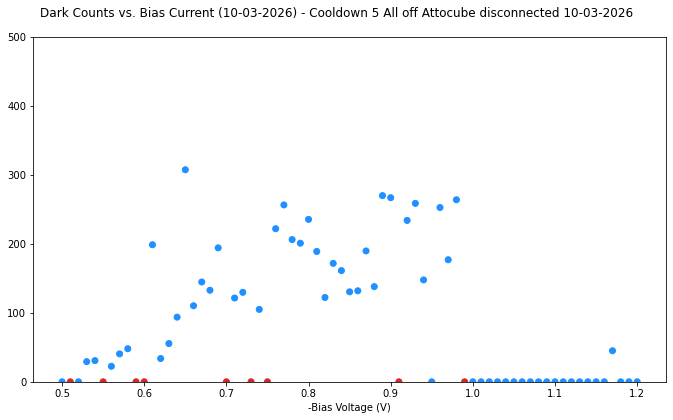

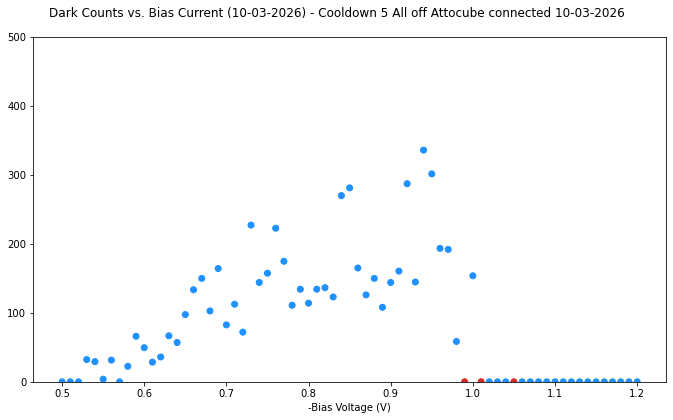

In [13]:
ylims = [0, 500]
date = '10-03-2026'
desc = [fr'Cooldown 5 All off Attocube disconnected {date}',
        fr'Cooldown 5 All off Attocube connected {date}']
cols = ['dodgerblue']

i = 0
for csv in glob.glob('C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/2026-03-10/dark/*'):
    # process
    dark = snshp.process_dark(csv,
                       intTime = 4,
                       countTimeRatio = 200/600)

    # plot
    plot_dark(dark,
             colChoice = cols,
             ylim = ylims,
             runID = desc[i],
             date = date,
             desc = desc[i],
             save = True)
    i += 1

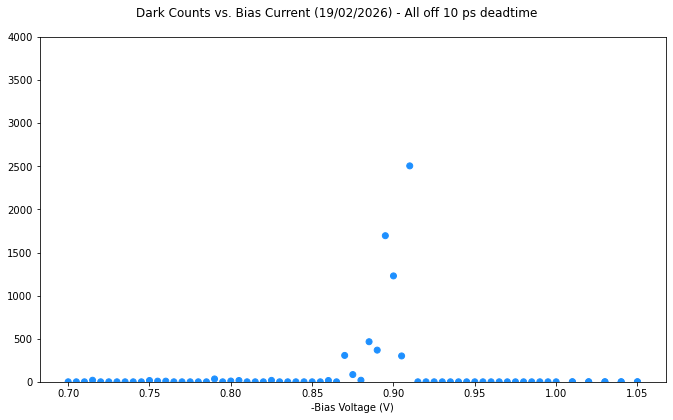

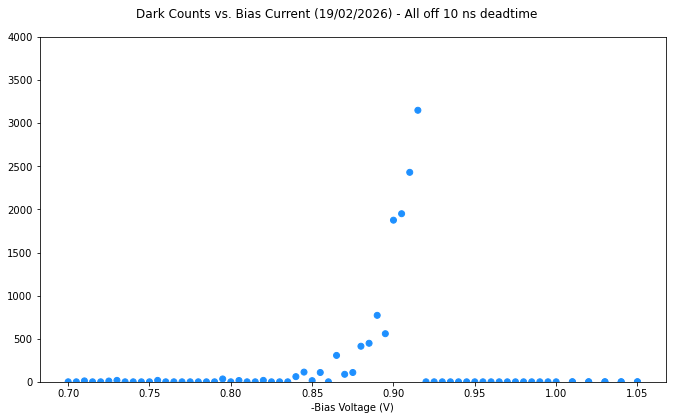

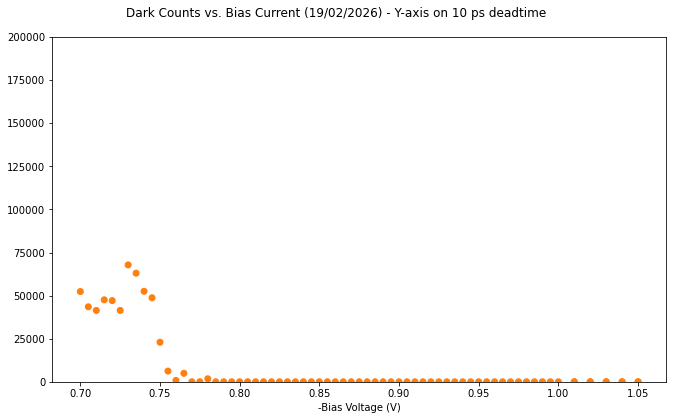

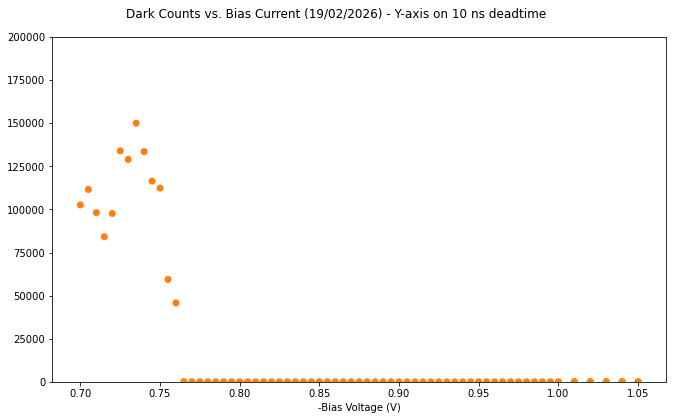

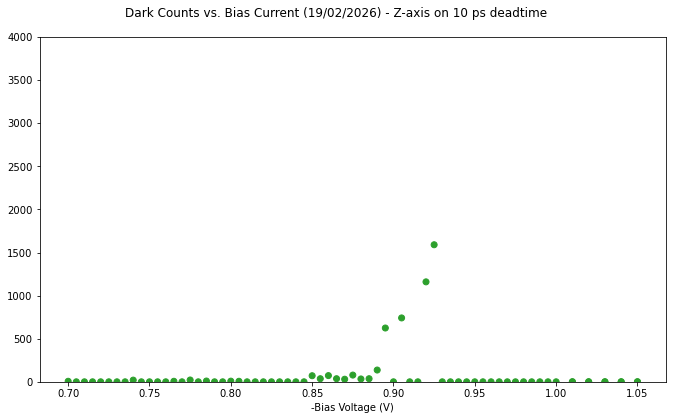

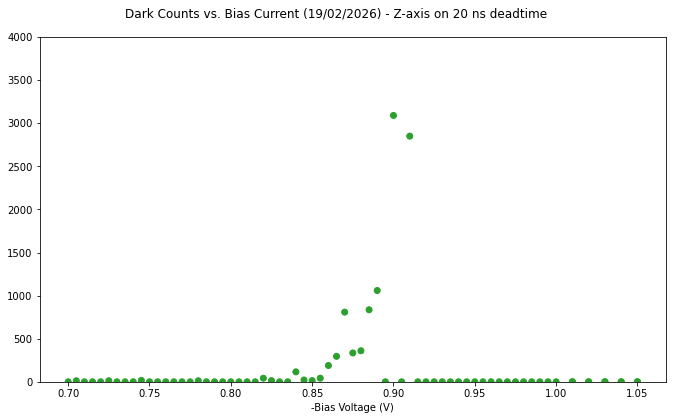

In [78]:
ylims = [[0, 4e3], [0, 4e3], 
         [0, 2e5], [0, 2e5],
         [0, 4e3], [0, 4e3]]
desc = ['All off 10 ps deadtime', 'All off 10 ns deadtime',
        'Y-axis on 10 ps deadtime', 'Y-axis on 10 ns deadtime', 
        'Z-axis on 10 ps deadtime', 'Z-axis on 20 ns deadtime',]
cols = ['dodgerblue', 'dodgerblue',
        'tab:orange', 'tab:orange',
        'tab:green', 'tab:green']

i = 0
for csv in glob.glob('C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/2026-02-19/dark/*'):
    # process
    dark = snshp.process_dark(csv,
                       intTime = 2,
                       countTimeRatio = 200/600)

    # plot
    plot_dark(dark,
             colChoice = cols[i],
             runID = desc[i],
             ylim = ylims[i],
             date = '19/02/2026',
             desc = desc[i],
             save = True)
    i += 1